###Kode Random Forest dan XGBoost dengan ada F class
by Group 13

In [ ]:
import pandas as pd

df = pd.read_csv('./Students Performance Dataset.csv', low_memory=False)
df.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Total_Score', 'Attendance (%)',
                 'Final_Score', 'Projects_Score'], inplace=True)
df.shape

(5000, 15)

In [ ]:
df.head()

,Gender,Age,Department,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Mathematics,40.61,73.69,53.17,73.4,F,10.3,Yes,No,Master's,Medium,1,5.9
1,Male,18,Business,57.27,74.23,98.23,88.0,B,27.1,No,No,High School,Low,4,4.3
2,Male,24,Engineering,41.84,85.85,50.00,4.7,D,12.4,Yes,No,High School,Low,9,6.1
3,Female,24,Engineering,45.65,68.10,66.27,4.2,F,25.5,No,Yes,High School,Low,8,4.9
4,Female,23,CS,53.13,67.66,83.98,64.3,C,13.3,Yes,No,Master's,Medium,6,4.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   object 
 3   Midterm_Score               5000 non-null   float64
 4   Assignments_Avg             5000 non-null   float64
 5   Quizzes_Avg                 5000 non-null   float64
 6   Participation_Score         5000 non-null   float64
 7   Grade                       5000 non-null   object 
 8   Study_Hours_per_Week        5000 non-null   float64
 9   Extracurricular_Activities  5000 non-null   object 
 10  Internet_Access_at_Home     5000 non-null   object 
 11  Parent_Education_Level      3975 non-null   object 
 12  Family_Income_Level         5000 non-null   object 
 13  Stress_Level (1-10)         5000 

In [ ]:
df = df[df['Grade'] != 'A']

In [ ]:
df.shape

(4984, 15)

In [ ]:
df['Grade'].value_counts()

,count
Grade,
C,2307
D,1760
B,638
F,279


In [ ]:
df.describe()

,Age,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000
mean,21.047753,70.636906,74.908740,74.797145,49.877769,17.517255,5.506421,6.513102
std,1.990981,17.421557,14.394863,14.422735,28.977807,7.196548,2.887127,1.446494
min,18.000000,40.000000,50.000000,50.000000,0.000000,5.000000,1.000000,4.000000
25%,19.000000,55.647500,62.327500,62.337500,25.000000,11.500000,3.000000,5.300000
50%,21.000000,70.730000,75.005000,74.820000,49.400000,17.400000,6.000000,6.500000
75%,23.000000,85.640000,87.230000,87.272500,75.425000,23.700000,8.000000,7.800000
max,24.000000,99.990000,99.990000,99.990000,100.000000,30.000000,10.000000,9.000000


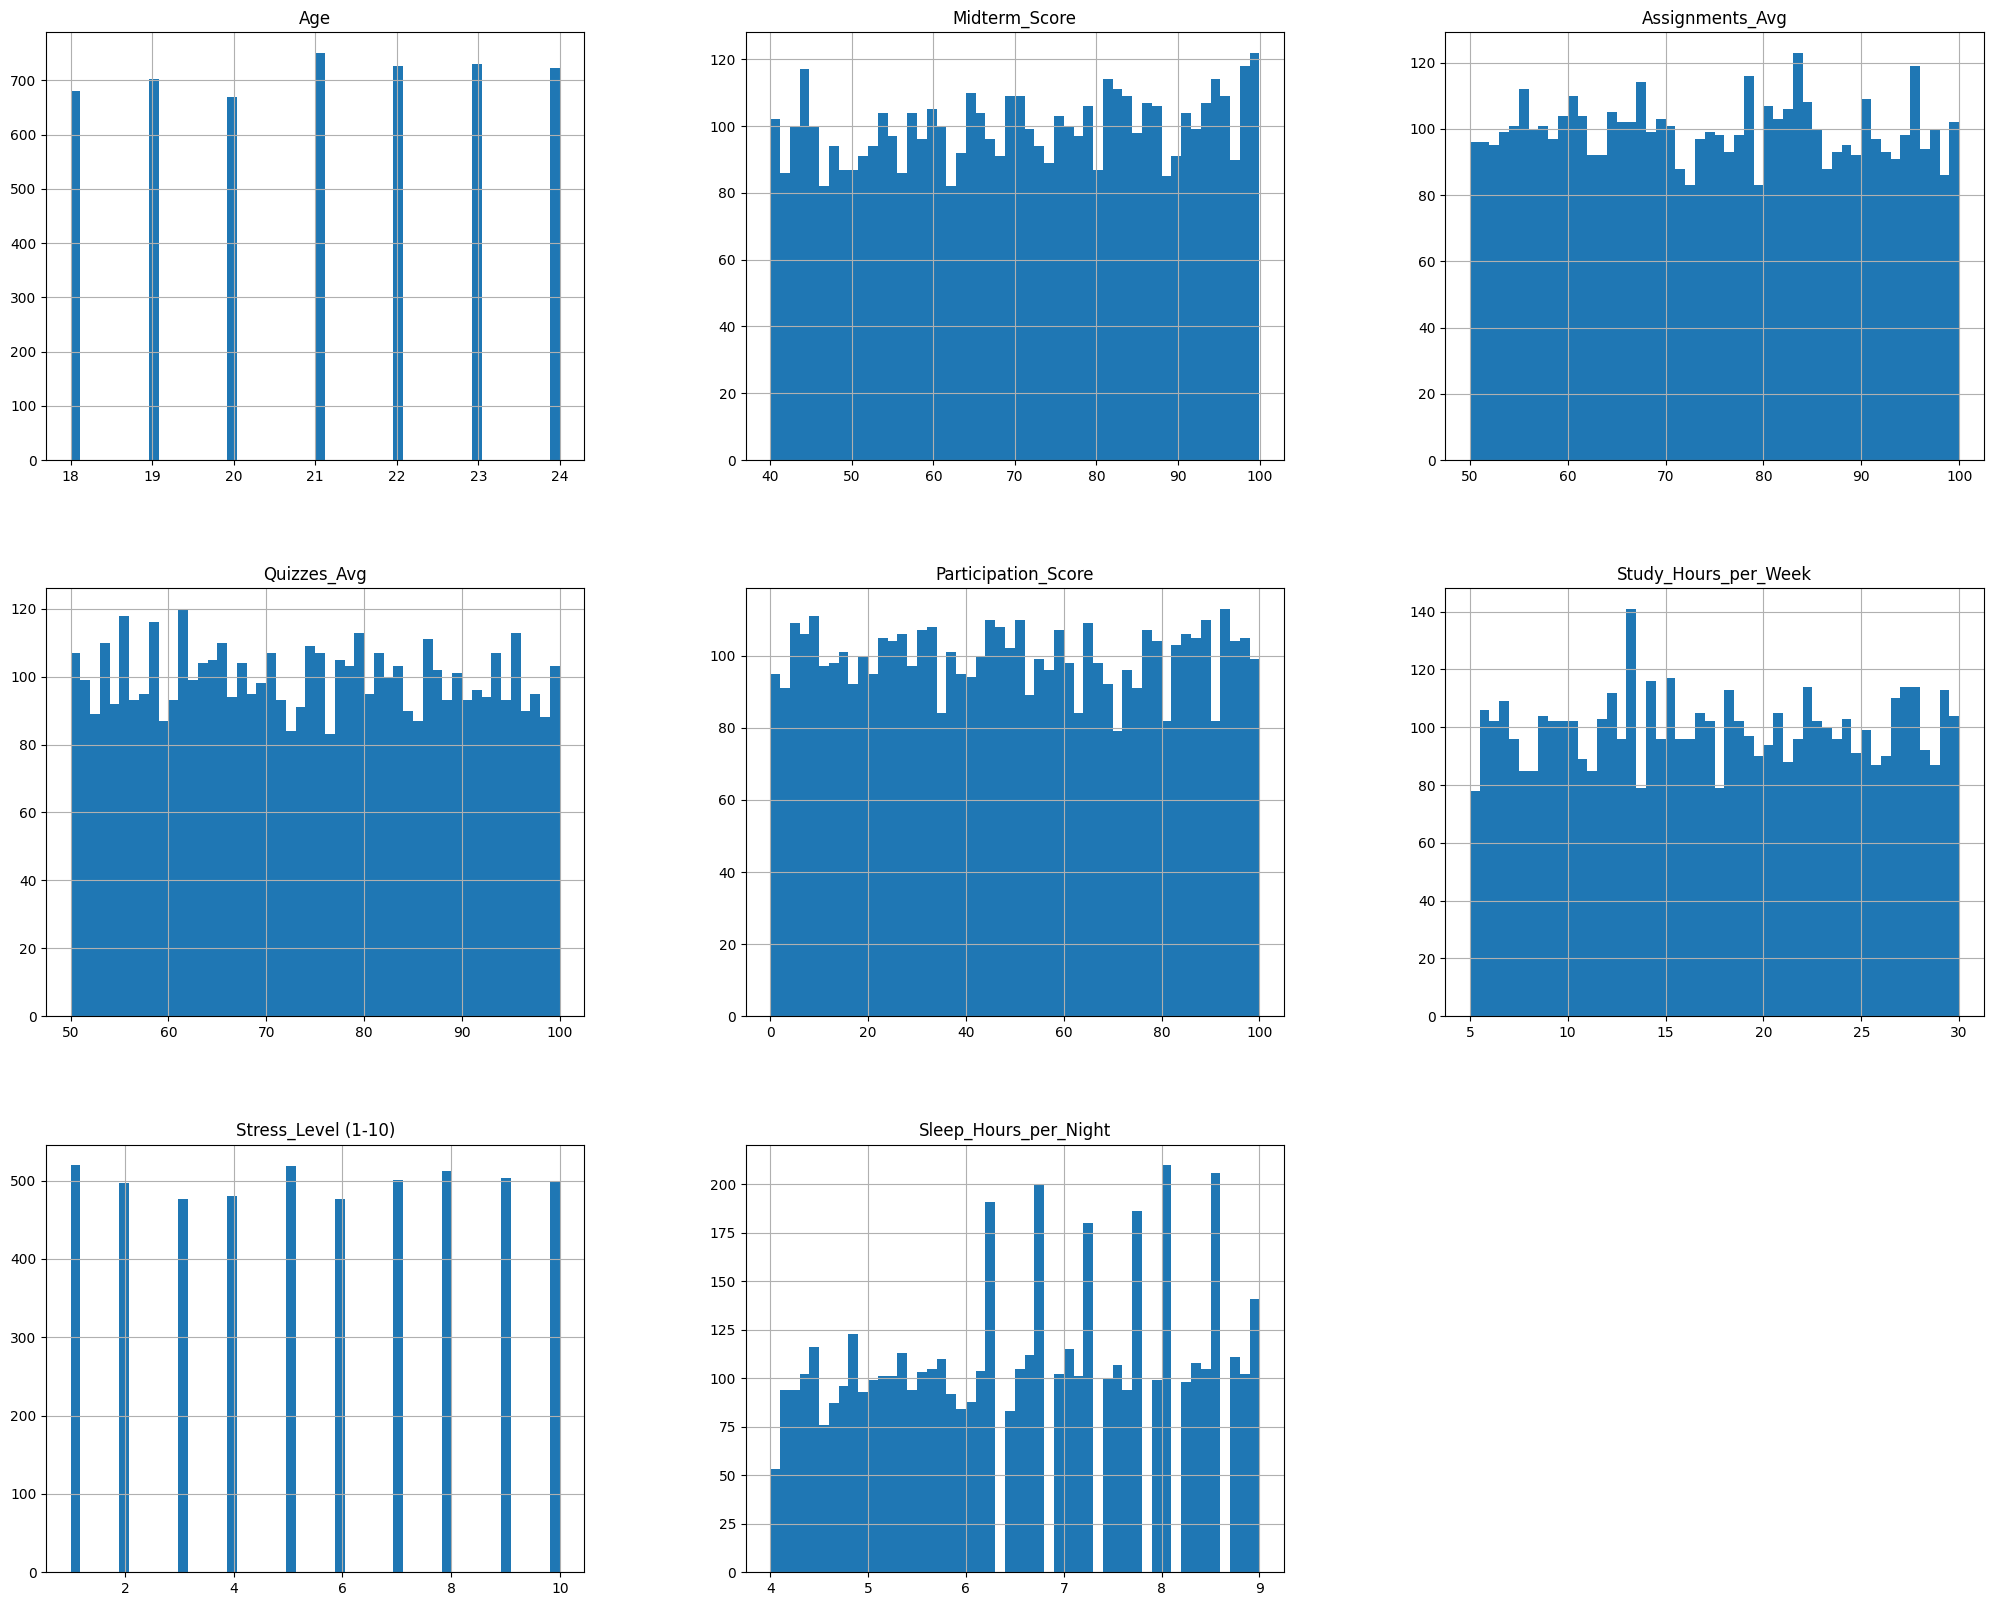

In [ ]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(25, 20))
plt.show()

In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
Department,0
Midterm_Score,0
Assignments_Avg,0
Quizzes_Avg,0
Participation_Score,0
Grade,0
Study_Hours_per_Week,0
Extracurricular_Activities,0


In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
Gender,0.000000
Age,0.000000
Department,0.000000
Midterm_Score,0.000000
Assignments_Avg,0.000000
Quizzes_Avg,0.000000
Participation_Score,0.000000
Grade,0.000000
Study_Hours_per_Week,0.000000
Extracurricular_Activities,0.000000


In [ ]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print("\n")

Gender
Male      2543
Female    2441
Name: count, dtype: int64


Department
Engineering    1270
Business       1262
CS             1234
Mathematics    1218
Name: count, dtype: int64


Grade
C    2307
D    1760
B     638
F     279
Name: count, dtype: int64


Extracurricular_Activities
Yes    2503
No     2481
Name: count, dtype: int64


Internet_Access_at_Home
Yes    2509
No     2475
Name: count, dtype: int64


Parent_Education_Level
Bachelor's     1017
PhD            1011
Master's        993
High School     940
Name: count, dtype: int64


Family_Income_Level
Low       1684
Medium    1670
High      1630
Name: count, dtype: int64




### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Grade', axis=1)
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,  stratify=y)
print(f"\ntraining set = {len(X_train)} baris")
print(f"test set = {len(X_test)} baris")

print(f"\nShape X_train (mentah): {X_train.shape}")
print(f"Shape X_test (mentah): {X_test.shape}")
print(f"Kolom X_train: {X_train.columns.tolist()}")

#Cek distribusi Grade di training set (harus mirip dengan asli)
print("\nDistribusi Grade di Training Set:")
print(y_train.value_counts(normalize=True))


training set = 3987 baris
test set = 997 baris

Shape X_train (mentah): (3987, 14)
Shape X_test (mentah): (997, 14)
Kolom X_train: ['Gender', 'Age', 'Department', 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

Distribusi Grade di Training Set:
Grade
C    0.463005
D    0.353148
B    0.127916
F    0.055932
Name: proportion, dtype: float64


###EDA Lebih lanjut

In [ ]:
#EDA TRAINING SET
print("EDA MENDALAM PADA TRAINING SET")
train_df = X_train.copy()
train_df['Grade'] = y_train

print(f"Shape: {train_df.shape}")

EDA MENDALAM PADA TRAINING SET
Shape: (3987, 15)


In [ ]:
#Encode grade ke numerik utk cek korelasi (Ordinal encode)
grade_order = {'F':0, 'D':1, 'C':2, 'B':3}
train_df['Grade_Num'] = train_df['Grade'].map(grade_order)

print(train_df[['Grade', 'Grade_Num']].drop_duplicates().sort_values('Grade_Num'))

     Grade  Grade_Num
4275     F          0
3537     D          1
1726     C          2
4701     B          3


BOX PLOT, DISTRIBUSI PER GRADE


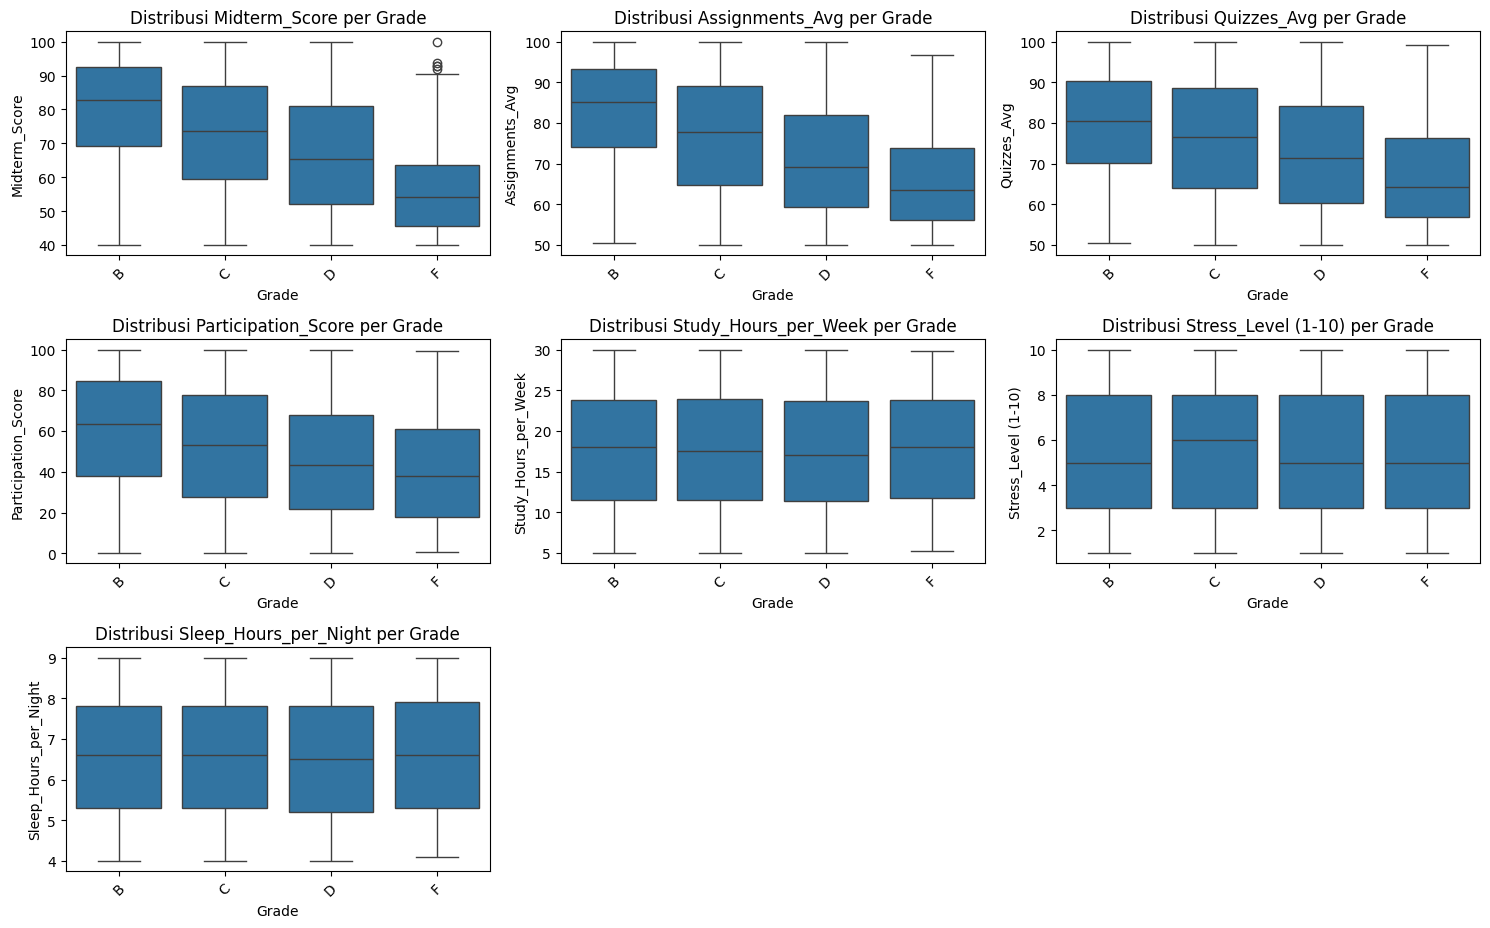

ITU MERUPAKAN BOX PLOT DISTRIBUSI PER GRADE
------------------------------------------------------------------------------------------

=== KORELASI DENGAN GRADE ===
Midterm_Score: 0.3044
Quizzes_Avg: 0.1927
Assignments_Avg: 0.2992
Participation_Score: 0.1692
Study_Hours_per_Week: 0.0096
Stress_Level (1-10): 0.0219
Sleep_Hours_per_Night: 0.0085
Age: 0.0002


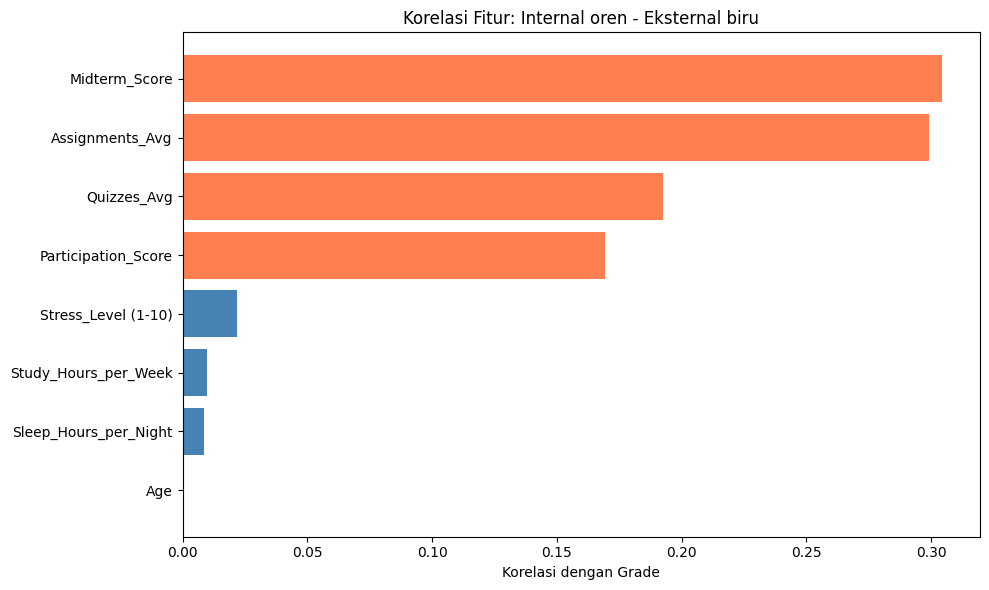


=== Scatter Matriks ===


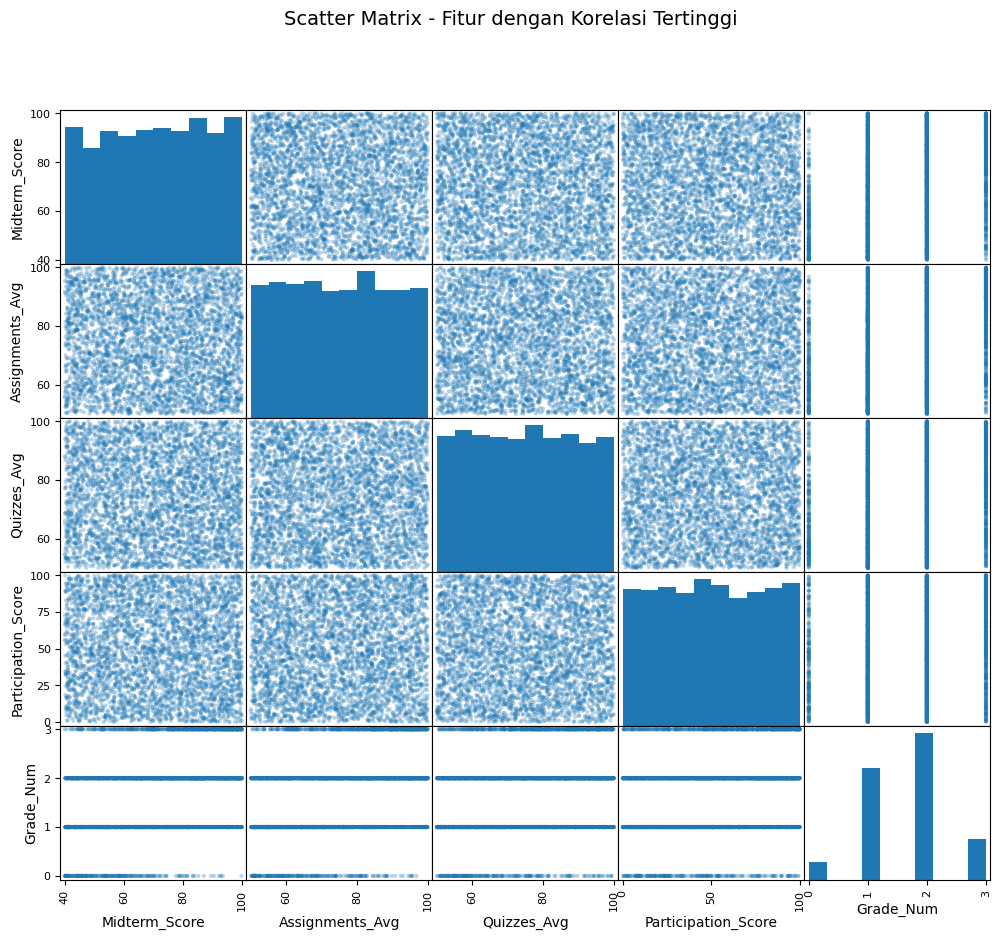

heatmap


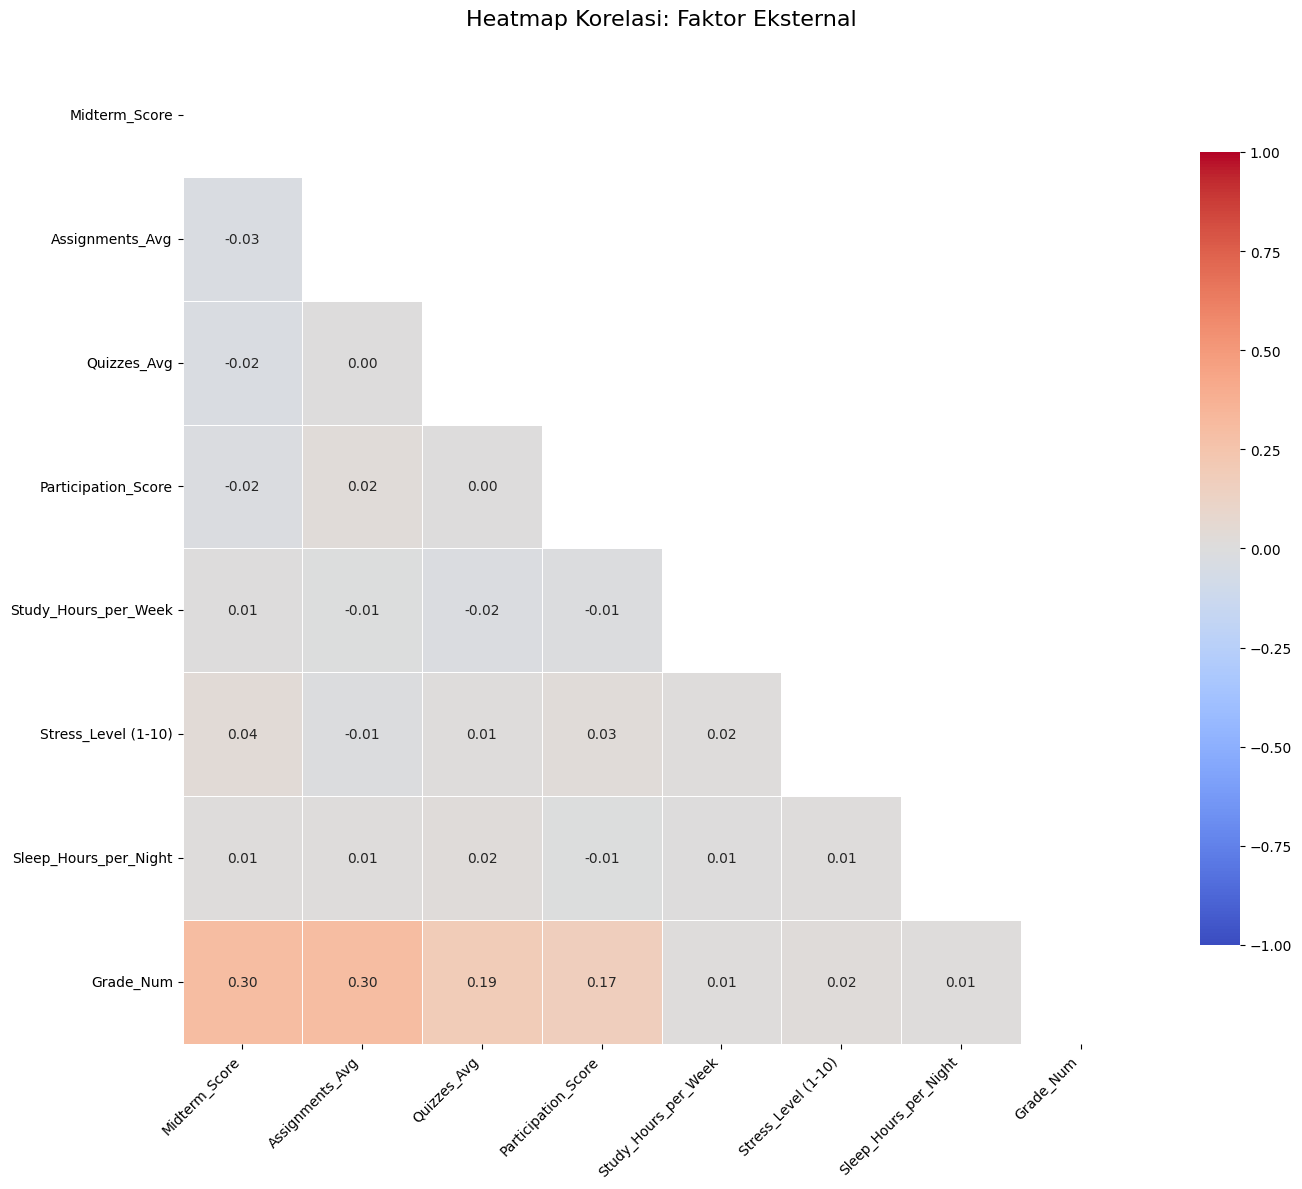


=== Analisis Missing Values ===
                        Jumlah missing values  Persentase (%)
Parent_Education_Level                    805        20.19062

=== Analisis Outlier ===
Midterm_Score: 0 outliers (0.0%)
Assignments_Avg: 0 outliers (0.0%)
Quizzes_Avg: 0 outliers (0.0%)
Participation_Score: 0 outliers (0.0%)
Study_Hours_per_Week: 0 outliers (0.0%)
Stress_Level (1-10): 0 outliers (0.0%)
Sleep_Hours_per_Night: 0 outliers (0.0%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#FITUR INTERNAL & EKSTERNAL
internal_cols = ['Midterm_Score', 'Quizzes_Avg', 'Assignments_Avg', 'Participation_Score']

external_cols = ['Study_Hours_per_Week', 'Extracurricular_Activities',
                 'Internet_Access_at_Home', 'Parent_Education_Level',
                 'Family_Income_Level', 'Stress_Level (1-10)',
                 'Sleep_Hours_per_Night', 'Age']


#BOX PLOT (Distribusi per Grade)
numeric_internal = ['Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score']
numeric_external = ['Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

all_num_cols = numeric_internal + numeric_external

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(all_num_cols):
    if col in train_df.columns:
        sns.boxplot(data=train_df, x='Grade', y=col, ax=axes[i], order=['B','C','D','F'])
        axes[i].set_title(f'Distribusi {col} per Grade')
        axes[i].tick_params(axis='x', rotation=45)

for j in range(len(all_num_cols), len(axes)):
    fig.delaxes(axes[j])

print("BOX PLOT, DISTRIBUSI PER GRADE")
plt.tight_layout()
plt.show()
print("ITU MERUPAKAN BOX PLOT DISTRIBUSI PER GRADE")
print("---"*30)



#KORELASI (INTERNALVS EKSTERNAL)
print("\n=== KORELASI DENGAN GRADE ===")
all_correlations = {}

all_cols_test = internal_cols + external_cols

for col in all_cols_test:
    if col in train_df.columns and train_df[col].dtype != 'object':
        all_correlations[col] = train_df[col].corr(train_df['Grade_Num'])
        print(f"{col}: {all_correlations[col]:.4f}")

# Visualisasi korelasi
corr_df = pd.DataFrame(all_correlations.items(), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['coral' if f in internal_cols else 'steelblue' for f in corr_df['Feature']]
plt.barh(corr_df['Feature'], corr_df['Correlation'], color=colors)
plt.xlabel('Korelasi dengan Grade')
plt.title('Korelasi Fitur: Internal oren - Eksternal biru')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#SCATTER MATRIX (FITUR KORELASI TERTINGGI)
print("\n=== Scatter Matriks ===")
top_features = corr_df.head(4)['Feature'].tolist()
top_features_with_grade = top_features + ['Grade_Num']

from pandas.plotting import scatter_matrix
scatter_matrix(train_df[top_features_with_grade], figsize=(12, 10), alpha=0.3)
plt.suptitle('Scatter Matrix - Fitur dengan Korelasi Tertinggi', size=14)
plt.show()


#TES HEATMAP DLU
print("heatmap")
cols_to_correlate = all_num_cols + ['Grade_Num']
corr_matrix = train_df[cols_to_correlate].corr()

plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",     #Biru negatif, Merah positif
            vmin=-1, vmax=1,     #korelasi Pearson
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Heatmap Korelasi: Faktor Eksternal', size=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#ANALISIS MISSING VALUE
print("\n=== Analisis Missing Values ===")
missing = train_df.isnull().sum()
missing_pct = 100 * missing / len(train_df)
missing_df = pd.DataFrame({'Jumlah missing values' : missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah missing values'] > 0])


#ANALISIS OUTLIER (IQR Method)
print("\n=== Analisis Outlier ===")
for col in all_num_cols:
    if col in train_df.columns:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
        print(f"{col}: {len(outliers)} outliers ({100*len(outliers)/len(train_df)}%)")


### Eksplor Korelasi Non Linear



=== MUTUAL INFORMATION (NON-LINEAR CORRELATION) ===
Skor Mutual Information:
 Midterm_Score                 0.056116
Assignments_Avg               0.045894
Participation_Score           0.034262
Quizzes_Avg                   0.021938
Age                           0.017721
Sleep_Hours_per_Night         0.014367
Extracurricular_Activities    0.013767
Study_Hours_per_Week          0.005876
Family_Income_Level           0.001169
Gender                        0.000000
Department                    0.000000
Internet_Access_at_Home       0.000000
Parent_Education_Level        0.000000
Stress_Level (1-10)           0.000000
dtype: float64


/tmp/ipykernel_5562/2466838189.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')


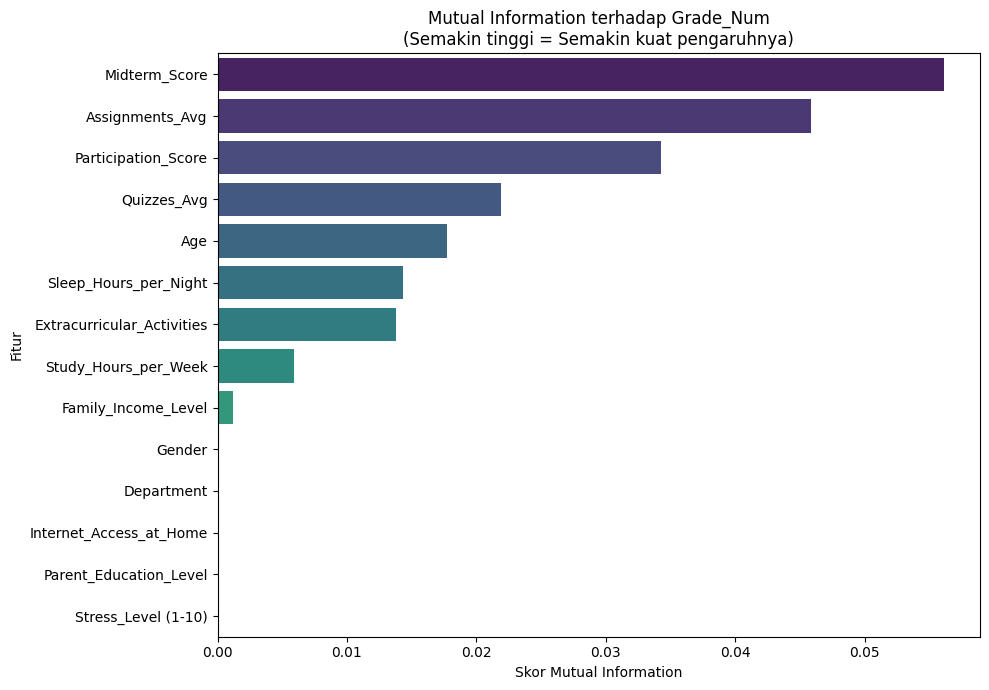

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== MUTUAL INFORMATION (NON-LINEAR CORRELATION) ===")


df_mi = train_df.copy()

cat_cols = df_mi.select_dtypes(include=['object']).columns

if 'Grade' in cat_cols:
    cat_cols = cat_cols.drop('Grade')

#label encoder
le = LabelEncoder()
for col in cat_cols:
    #Mengisi missing value sementara unknown agar tak error saat diencode
    df_mi[col] = df_mi[col].fillna('Unknown')
    df_mi[col] = le.fit_transform(df_mi[col].astype(str))


X_mi = df_mi.drop(columns=['Grade', 'Grade_Num'], errors='ignore')
y_mi = df_mi['Grade_Num']
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)


mi_series = pd.Series(mi_scores, index=X_mi.columns)
mi_series = mi_series.sort_values(ascending=False)

print("Skor Mutual Information:\n", mi_series)

plt.figure(figsize=(10, 7))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.title('Mutual Information terhadap Grade_Num\n(Semakin tinggi = Semakin kuat pengaruhnya)')
plt.xlabel('Skor Mutual Information')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


=== EDA FITUR KATEGORIKAL ===


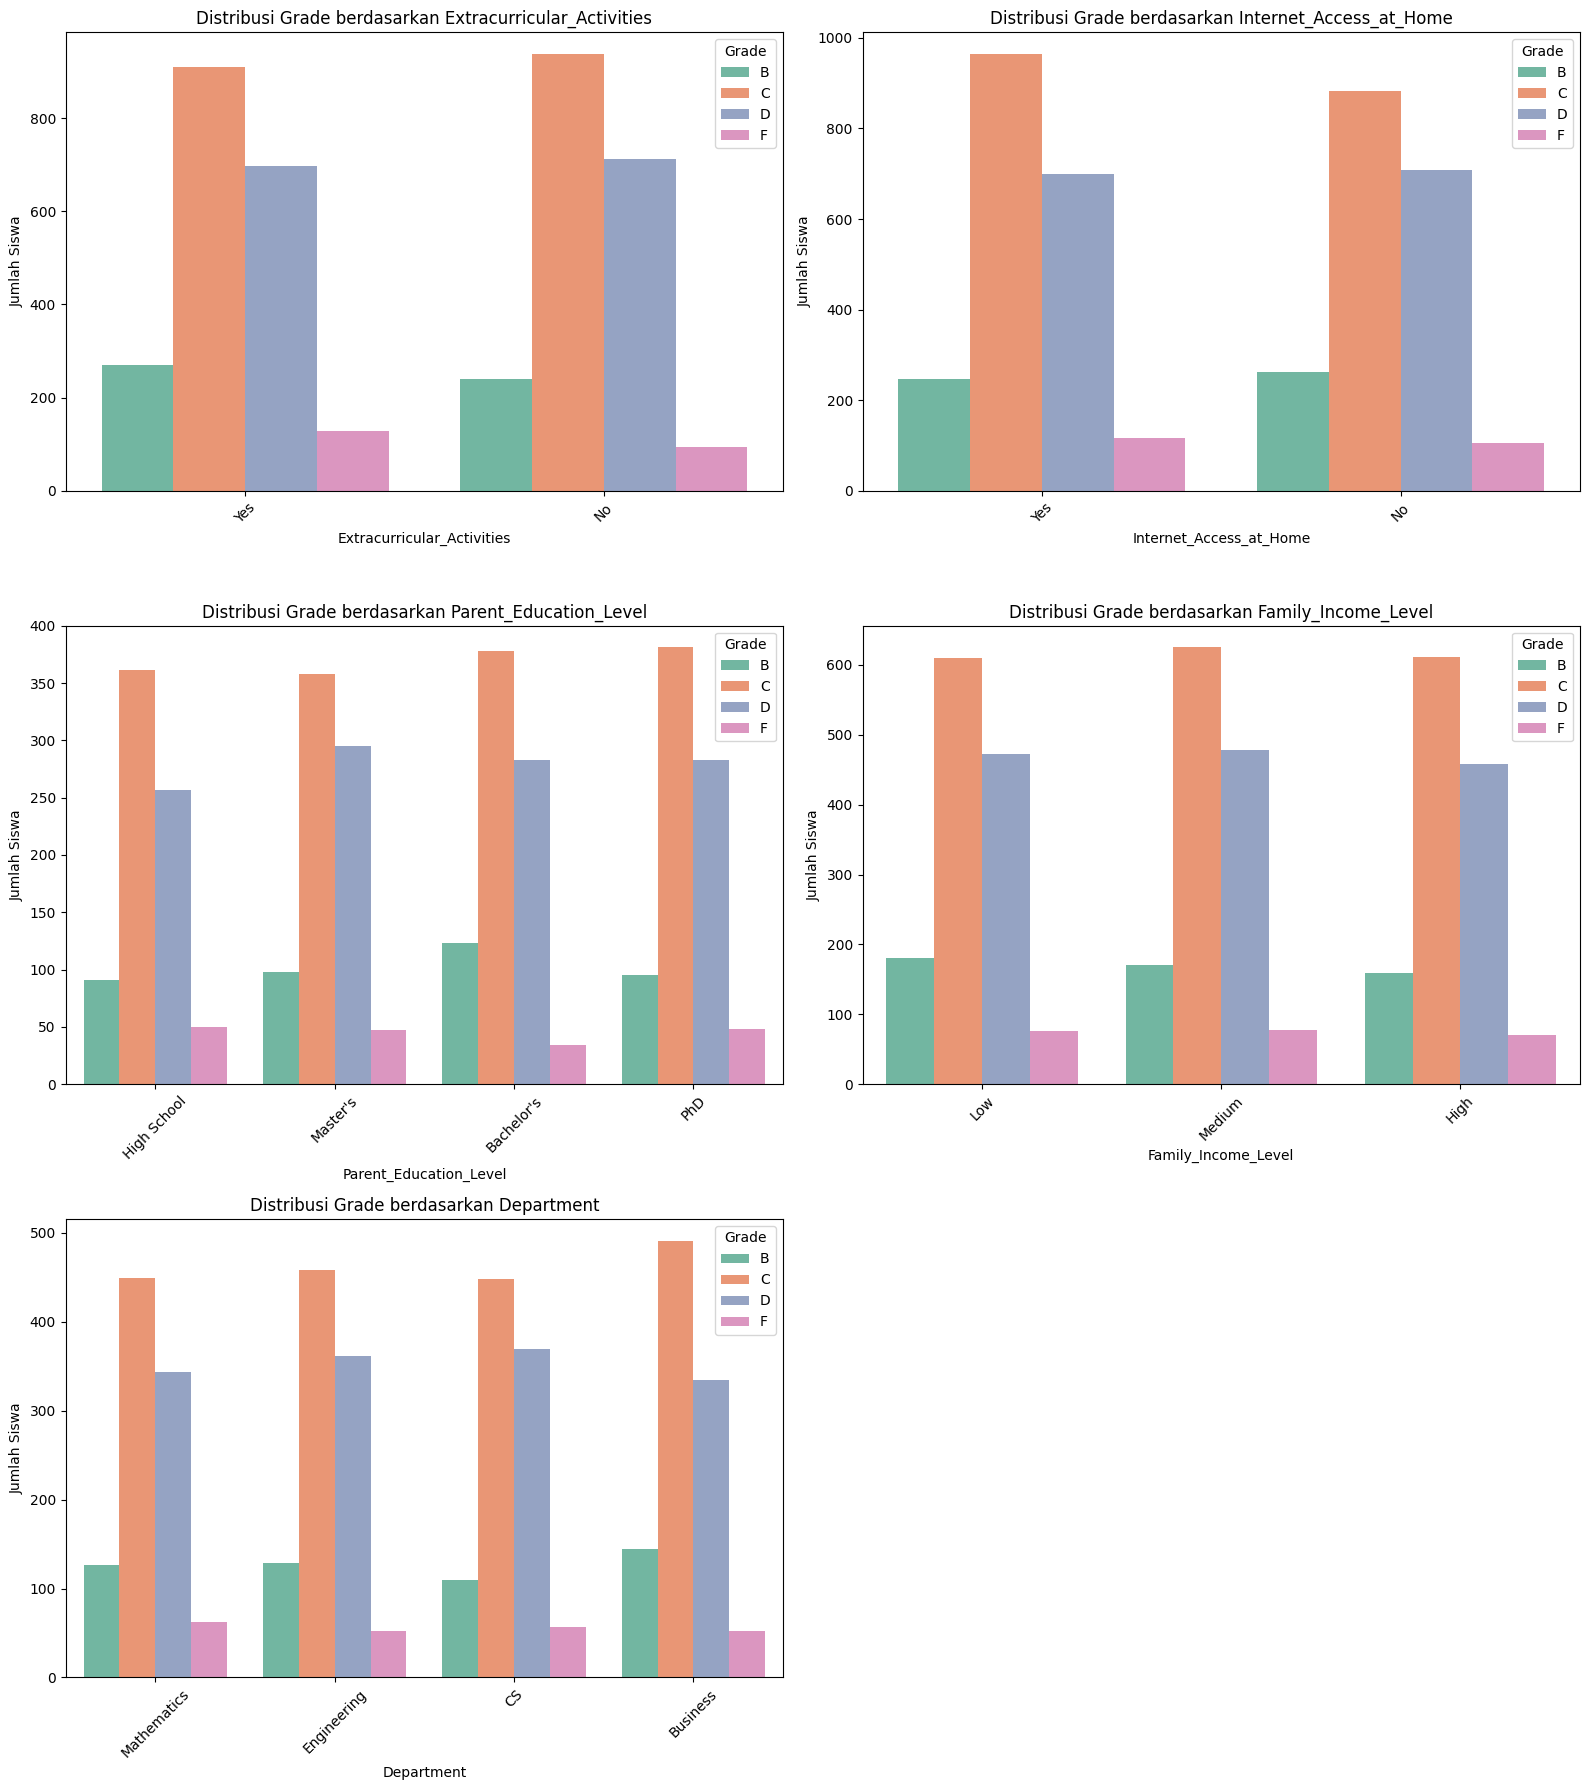

In [ ]:
#EDA FITUR KATEGORIKAL VS TARGET
print("\n=== EDA FITUR KATEGORIKAL ===")

cat_cols = ['Extracurricular_Activities', 'Internet_Access_at_Home',
            'Parent_Education_Level', 'Family_Income_Level', 'Department']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    if col in train_df.columns:
        sns.countplot(data=train_df, x=col, hue='Grade',
                      hue_order=['B', 'C', 'D', 'F'],
                      ax=axes[i], palette='Set2')
        axes[i].set_title(f'Distribusi Grade berdasarkan {col}', size=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Jumlah Siswa')


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

print("\n=== KORELASI FITUR KATEGORIKAL VS GRADE ===")

cat_cols = ['Gender', 'Extracurricular_Activities', 'Internet_Access_at_Home',
            'Parent_Education_Level', 'Family_Income_Level', 'Department']

for col in cat_cols:
    if col in train_df.columns:

        crosstab = pd.crosstab(train_df[col], train_df['Grade'])

        chi2, p, dof, expected = chi2_contingency(crosstab)

        n = crosstab.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))

        print(f"\n--- {col} ---")
        print(f"Chi-Square: {chi2:.4f}")
        print(f"p-value: {p:.4f}")
        print(f"Cramér's V: {cramers_v:.4f}")

        if p < 0.05:
            print("Signifikan (p < 0.05)")
        else:
            print("Tidak signifikan (p >= 0.05)")


=== KORELASI FITUR KATEGORIKAL VS GRADE ===

--- Gender ---
Chi-Square: 2.7945
p-value: 0.4244
Cramér's V: 0.0265
Tidak signifikan (p >= 0.05)

--- Extracurricular_Activities ---
Chi-Square: 7.9752
p-value: 0.0465
Cramér's V: 0.0447
Signifikan (p < 0.05)

--- Internet_Access_at_Home ---
Chi-Square: 3.5394
p-value: 0.3157
Cramér's V: 0.0298
Tidak signifikan (p >= 0.05)

--- Parent_Education_Level ---
Chi-Square: 10.9877
p-value: 0.2766
Cramér's V: 0.0339
Tidak signifikan (p >= 0.05)

--- Family_Income_Level ---
Chi-Square: 1.2288
p-value: 0.9754
Cramér's V: 0.0124
Tidak signifikan (p >= 0.05)

--- Department ---
Chi-Square: 9.5564
p-value: 0.3876
Cramér's V: 0.0283
Tidak signifikan (p >= 0.05)


###Preprocessing
Handle missing values, feature engineering, encoding

In [ ]:
#DATA CLEANING
from sklearn.impute import SimpleImputer

col_to_impute = ['Parent_Education_Level']
imputer = SimpleImputer(strategy='most_frequent') #modus
imputer.fit(X_train[col_to_impute])

X_train_imputed = X_train.copy()
X_train_imputed[col_to_impute] = imputer.transform(X_train[col_to_impute])


X_test_imputed = X_test.copy()

#hasil
print("=== SETELAH IMPUTASI ===")
print(f"Missing value di TRAINING SET: {X_train_imputed['Parent_Education_Level'].isnull().sum()}")
print(f"Missing value di TEST SET: {X_test['Parent_Education_Level'].isnull().sum()}")

#distribusi
print("\n=== DISTRIBUSI PARENT_EDUCATION_LEVEL (TRAINING SET) ===")
print(X_train_imputed['Parent_Education_Level'].value_counts())

=== SETELAH IMPUTASI ===
Missing value di TRAINING SET: 0
Missing value di TEST SET: 218

=== DISTRIBUSI PARENT_EDUCATION_LEVEL (TRAINING SET) ===
Parent_Education_Level
Bachelor's     1623
PhD             807
Master's        798
High School     759
Name: count, dtype: int64


In [ ]:
# FEATURE ENGINEERING
def apply_feature_engineering(data):
    df_engineered = data.copy()

    weekly_sleep = (df_engineered['Sleep_Hours_per_Night'] * 7)

    #1: Rasio Belajar per Jam Tidur (deteksi burnout)
    df_engineered['Study_Sleep_Ratio'] = df_engineered['Study_Hours_per_Week'] / (weekly_sleep + 0.1)


    #2: Indeks Sosial Ekonomi (SES Score)
    income_weights = {'Low': 1, 'Medium': 2, 'High': 3}
    edu_weights = {'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4, 'Unknown': 0}

    income_score = df_engineered['Family_Income_Level'].map(income_weights).fillna(0)
    edu_score = df_engineered['Parent_Education_Level'].map(edu_weights).fillna(0)

    df_engineered['SES_Score'] = income_score + edu_score


    #3: Total Beban Waktu (Time Load)
    extra_hours = np.where(df_engineered['Extracurricular_Activities'] == 'Yes', 10, 0)

    #hitung total beban akademik per minggu
    df_engineered['Total_Weekly_Load'] = df_engineered['Study_Hours_per_Week'] + extra_hours

    #rasio Beban Total vs Istirahat
    df_engineered['Load_Sleep_Ratio'] = df_engineered['Total_Weekly_Load'] / (weekly_sleep + 0.1)

    return df_engineered

X_train_fe = apply_feature_engineering(X_train_imputed)
X_test_fe = apply_feature_engineering(X_test_imputed)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import pandas as pd


X_train_ready = X_train_fe.copy()
X_test_ready = X_test_fe.copy()


# 1. LABEL ENCODING
label_cols = ['Gender', 'Extracurricular_Activities', 'Internet_Access_at_Home']

label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    X_train_ready[col] = le.fit_transform(X_train_ready[col])
    X_test_ready[col] = le.transform(X_test_ready[col])
    label_encoders[col] = le
    # print mapping
    print(f"{col}: {dict(zip(le.classes_, range(len(le.classes_))))}")


# 2. ORDINAL ENCODING
# ubah nan jdi unknown teks
X_train_ready['Parent_Education_Level'] = X_train_ready['Parent_Education_Level'].fillna('Unknown')
X_test_ready['Parent_Education_Level'] = X_test_ready['Parent_Education_Level'].fillna('Unknown')

X_train_ready['Family_Income_Level'] = X_train_ready['Family_Income_Level'].fillna('Unknown')
X_test_ready['Family_Income_Level'] = X_test_ready['Family_Income_Level'].fillna('Unknown')

parent_order = [['Unknown', 'High School', "Bachelor's", "Master's", 'PhD']]
income_order = [['Unknown', 'Low', 'Medium', 'High']]

ordinal_encoder_parent = OrdinalEncoder(categories=parent_order)
ordinal_encoder_income = OrdinalEncoder(categories=income_order)

X_train_ready['Parent_Education_Level'] = ordinal_encoder_parent.fit_transform(
    X_train_ready[['Parent_Education_Level']]
).astype(int)

X_test_ready['Parent_Education_Level'] = ordinal_encoder_parent.transform(
    X_test_ready[['Parent_Education_Level']]
).astype(int)

X_train_ready['Family_Income_Level'] = ordinal_encoder_income.fit_transform(
    X_train_ready[['Family_Income_Level']]
).astype(int)

X_test_ready['Family_Income_Level'] = ordinal_encoder_income.transform(
    X_test_ready[['Family_Income_Level']]
).astype(int)

print("\nParent_Education_Level mapping: Unknown=0, High School=1, Bachelor's=2, Master's=3, PhD=4")
print("Family_Income_Level mapping: Unknown=0, Low=1, Medium=2, High=3")


# 3. ONE-HOT ENCODING
X_train_encoded = pd.get_dummies(X_train_ready, columns=['Department'], prefix='Dept', dtype=int)
X_test_encoded = pd.get_dummies(X_test_ready, columns=['Department'], prefix='Dept', dtype=int)

for col in X_train_encoded.columns:
    if col not in X_test_encoded.columns:
        X_test_encoded[col] = 0

X_test_encoded = X_test_encoded[X_train_encoded.columns]


print("\n=== HASIL ENCODING ===")
print(f"Shape X_train_encoded: {X_train_encoded.shape}")
print(f"Shape X_test_encoded: {X_test_encoded.shape}")
print("\nTipe data setelah cleanup:")
print(X_train_encoded.dtypes.value_counts())

print("\n5 baris pertama X_train_imputed:")
print(X_train_encoded.head())

Gender: {'Female': 0, 'Male': 1}
Extracurricular_Activities: {'No': 0, 'Yes': 1}
Internet_Access_at_Home: {'No': 0, 'Yes': 1}

Parent_Education_Level mapping: Unknown=0, High School=1, Bachelor's=2, Master's=3, PhD=4
Family_Income_Level mapping: Unknown=0, Low=1, Medium=2, High=3

=== HASIL ENCODING ===
Shape X_train_encoded: (3987, 21)
Shape X_test_encoded: (997, 21)

Tipe data setelah cleanup:
int64      12
float64     9
Name: count, dtype: int64

5 baris pertama X_train_imputed:
      Gender  Age  Midterm_Score  Assignments_Avg  Quizzes_Avg  \
4701       0   18          93.54            96.76        64.87   
3537       0   20          75.24            55.75        91.87   
4349       0   20          85.89            69.33        53.45   
815        1   23          53.14            74.73        90.21   
1726       1   21          91.57            82.09        60.41   

      Participation_Score  Study_Hours_per_Week  Extracurricular_Activities  \
4701                 69.9            

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

grade_order = [['B', 'C', 'D', 'F']]

ordinal_encoder_grade = OrdinalEncoder(categories=grade_order)

y_train_encoded = ordinal_encoder_grade.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype(int)
y_test_encoded = ordinal_encoder_grade.transform(y_test.values.reshape(-1, 1)).ravel().astype(int)

print(f"Mapping grade: B=0, C=1, D=2, F=3")
print(f"Distribusi y_train_encoded: {pd.Series(y_train_encoded).value_counts().sort_index().tolist()}")

Mapping grade: B=0, C=1, D=2, F=3
Distribusi y_train_encoded: [510, 1846, 1408, 223]


In [ ]:
#cek sebelum train
X_train_encoded.info()
X_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3987 entries, 4701 to 232
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      3987 non-null   int64  
 1   Age                         3987 non-null   int64  
 2   Midterm_Score               3987 non-null   float64
 3   Assignments_Avg             3987 non-null   float64
 4   Quizzes_Avg                 3987 non-null   float64
 5   Participation_Score         3987 non-null   float64
 6   Study_Hours_per_Week        3987 non-null   float64
 7   Extracurricular_Activities  3987 non-null   int64  
 8   Internet_Access_at_Home     3987 non-null   int64  
 9   Parent_Education_Level      3987 non-null   int64  
 10  Family_Income_Level         3987 non-null   int64  
 11  Stress_Level (1-10)         3987 non-null   int64  
 12  Sleep_Hours_per_Night       3987 non-null   float64
 13  Study_Sleep_Ratio           3987 non

###Install Scikit Optimize untuk Bayesian Optimization

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00


###Random Forest dengan Random Oversampling & Tuning

In [ ]:
from skopt import BayesSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report

print("=== SETUP BAYESIAN OPTIMIZATION DENGAN PIPELINE ===")

pipeline_rf = ImbPipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

search_space_rf = {
    'rf__n_estimators': (50, 300),
    'rf__max_depth': (5, 20),
    'rf__min_samples_split': (2, 20),
    'rf__min_samples_leaf': (1, 10),
    'rf__criterion': ['gini', 'entropy']
}

#3.Setup Bayesian Optimizer
bayes_search_rf = BayesSearchCV(
    estimator=pipeline_rf,
    search_spaces=search_space_rf,
    scoring='f1_macro',                    # metrik eval
    cv=3,
    n_iter=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


print("\nMemulai eksperimen pencarian parameter...")
bayes_search_rf.fit(X_train_encoded, y_train_encoded)


print("\n" + "="*40)
print("PARAMETER TERBAIK!")
print("="*40)
for param, value in bayes_search_rf.best_params_.items():
    print(f"- {param.replace('rf__', '')}: {value}")

print(f"\nF1-Macro Score Tertinggi saat CV: {bayes_search_rf.best_score_:.4f}")

#Evaluasi di Test Set
best_rf_model = bayes_search_rf.best_estimator_
y_pred_best = best_rf_model.predict(X_test_encoded)

print("\n" + "="*40)
print("REPORT EVALUASI TEST SET (REAL WORLD)")
print("="*40)

print(classification_report(y_test_encoded, y_pred_best, target_names=['B', 'C', 'D', 'F']))

#metrik pendukung
bal_acc = balanced_accuracy_score(y_test_encoded, y_pred_best)
print(f"Balanced Accuracy Score: {bal_acc:.4f}")

=== SETUP BAYESIAN OPTIMIZATION DENGAN PIPELINE ===

Memulai eksperimen pencarian parameter...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for 

In [ ]:
import joblib

nama_file = 'rf_best_model_ros.pkl'
joblib.dump(best_rf_model, nama_file)

print(f"Model disimpan dengan nama : {nama_file}")

Model disimpan dengan nama : rf_best_model_ros.pkl


In [ ]:
log_training = pd.DataFrame(bayes_search_rf.cv_results_)
kolom_penting = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
log_rapi = log_training[kolom_penting].sort_values(by='rank_test_score')

#simpan ke csv
nama_file_log = 'log_training_rf_ros.csv'
log_rapi.to_csv(nama_file_log, index=False)

print(f"Log history training berhasil disimpan ke: {nama_file_log}")

Log history training berhasil disimpan ke: log_training_rf_ros.csv



=== FEATURE IMPORTANCE (RANDOM FOREST) ===
                       Feature  Importance
2                Midterm_Score    0.190150
3              Assignments_Avg    0.160258
4                  Quizzes_Avg    0.113357
5          Participation_Score    0.092988
15           Total_Weekly_Load    0.055339
16            Load_Sleep_Ratio    0.054152
13           Study_Sleep_Ratio    0.053953
6         Study_Hours_per_Week    0.053848
12       Sleep_Hours_per_Night    0.049950
11         Stress_Level (1-10)    0.036222
1                          Age    0.031206
14                   SES_Score    0.021239
9       Parent_Education_Level    0.016926
10         Family_Income_Level    0.014025
8      Internet_Access_at_Home    0.010713
0                       Gender    0.010195
7   Extracurricular_Activities    0.007962
19            Dept_Engineering    0.007239
17               Dept_Business    0.007041
20            Dept_Mathematics    0.006901
18                     Dept_CS    0.006335


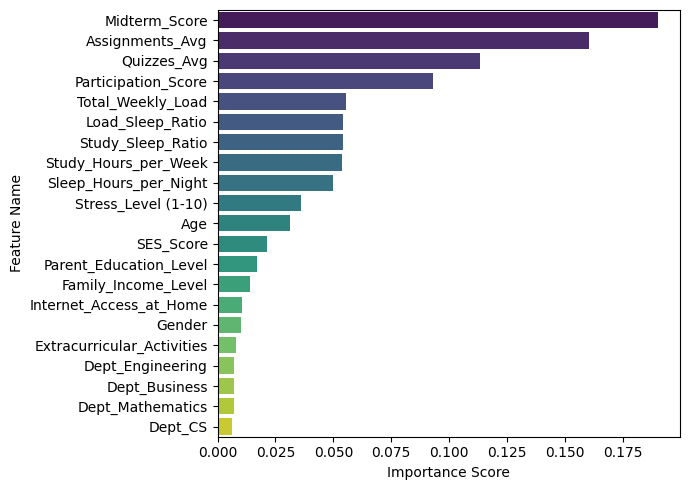

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


best_rf = best_rf_model.named_steps['rf']

feature_importances = best_rf.feature_importances_

feature_names = X_train_encoded.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n=== FEATURE IMPORTANCE (RANDOM FOREST) ===")
print(importance_df)

plt.figure(figsize=(7, 5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importance_rf.pdf')
plt.show()

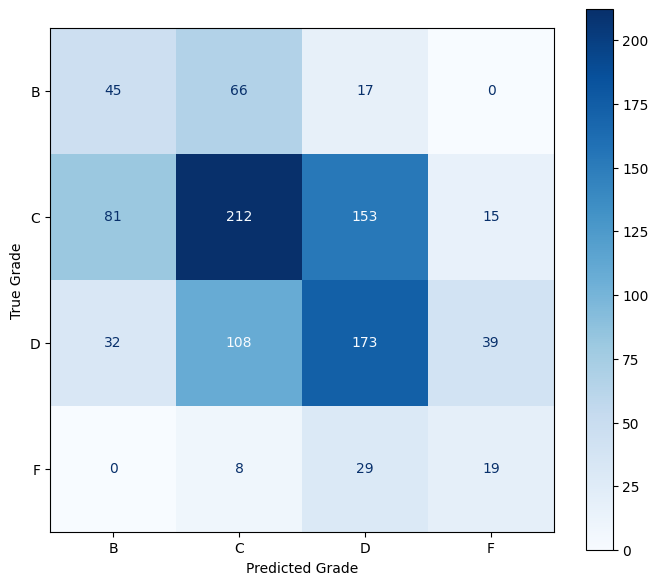

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'y_test_encoded' not in locals() or 'y_pred_best' not in locals():
    print("Error: 'y_test_encoded' or 'y_pred_best' not found. Please ensure all preceding cells (especially encoding and model training) have been executed successfully.")
else:
    cm = confusion_matrix(y_test_encoded, y_pred_best)
    class_names = ['B', 'C', 'D', 'F']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_xlabel('Predicted Grade')
    ax.set_ylabel('True Grade')
    plt.tight_layout()
    plt.savefig('confusion_matrix_rf_with_f.pdf')
    plt.show()

###Xgboost Random Oversampling & Tuning Bayesian Optimization

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import xgboost as xgb
from skopt import BayesSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import balanced_accuracy_score, classification_report, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== SETUP BAYESIAN OPTIMIZATION XGBOOST DENGAN PIPELINE ===")
pipeline_xgb = ImbPipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('xgb', xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

search_space_xgb = {
    'xgb__n_estimators': (50, 300),
    'xgb__max_depth': (3, 10),
    'xgb__learning_rate': (0.01, 0.3, 'log-uniform'),
    'xgb__subsample': (0.6, 1.0),
    'xgb__colsample_bytree': (0.6, 1.0)
}

bayes_search_xgb = BayesSearchCV(
    estimator=pipeline_xgb,
    search_spaces=search_space_xgb,
    scoring='f1_macro',                    # Metrik evaluasi
    cv=3,
    n_iter=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


print("\nMemulai eksperimen pencarian parameter XGBoost...")
bayes_search_xgb.fit(X_train_encoded, y_train_encoded)


print("\n" + "="*40)
print("PARAMETER TERBAIK")
print("="*40)
for param, value in bayes_search_xgb.best_params_.items():
    print(f"- {param.replace('xgb__', '')}: {value}")

print(f"\nF1-Macro Score Tertinggi saat CV: {bayes_search_xgb.best_score_:.4f}")

best_xgb_model = bayes_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_encoded)

print("\n" + "="*40)
print("REPORT EVALUASI TEST SET (REAL WORLD)")
print("="*40)

acc = accuracy_score(y_test_encoded, y_pred_xgb)
bal_acc = balanced_accuracy_score(y_test_encoded, y_pred_xgb)
f1_mac = f1_score(y_test_encoded, y_pred_xgb, average='macro')
f1_wei = f1_score(y_test_encoded, y_pred_xgb, average='weighted')

print(f"Accuracy Score          : {acc:.4f}")
print(f"Balanced Accuracy Score : {bal_acc:.4f}")
print(f"F1-Score (Weighted)     : {f1_wei:.4f}")
print(f"F1-Score (Macro)        : {f1_mac:.4f} \n")


print("Detail Per Kelas:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=['B', 'C', 'D', 'F']))


=== SETUP BAYESIAN OPTIMIZATION XGBOOST DENGAN PIPELINE ===

Memulai eksperimen pencarian parameter XGBoost...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitt

###Confusion Matrix

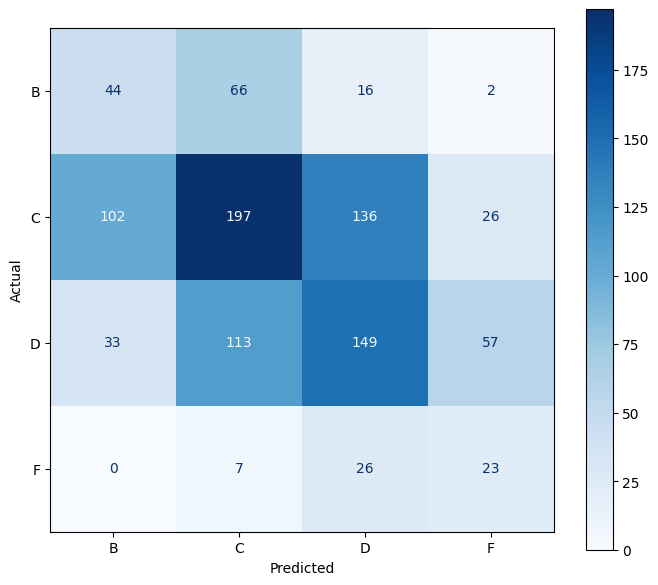

In [ ]:
cm = confusion_matrix(y_test_encoded, y_pred_xgb)
class_names = ['B', 'C', 'D', 'F']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_xgb_with_f.pdf')
plt.show()

In [ ]:
import joblib

#Simpan model
nama_file = 'xgb_best_model_ros.pkl'
joblib.dump(best_xgb_model, nama_file)

print(f"Model disimpan dengan nama: {nama_file}")

Model disimpan dengan nama: xgb_best_model_ros.pkl


In [ ]:
log_training = pd.DataFrame(bayes_search_xgb.cv_results_)


kolom_penting = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
log_rapi = log_training[kolom_penting].sort_values(by='rank_test_score')

#simpan ke csv
nama_file_log = 'log_training_xgb_ros.csv'
log_rapi.to_csv(nama_file_log, index=False)

print(f"Log history training sukses disimpan ke: {nama_file_log}")

Log history training sukses disimpan ke: log_training_xgb_ros.csv



=== FEATURE IMPORTANCE (XGBOOST) ===
                       Feature  Importance
2                Midterm_Score    0.102179
3              Assignments_Avg    0.083769
4                  Quizzes_Avg    0.062085
5          Participation_Score    0.053015
15           Total_Weekly_Load    0.045625
7   Extracurricular_Activities    0.044419
13           Study_Sleep_Ratio    0.044196
8      Internet_Access_at_Home    0.044050
16            Load_Sleep_Ratio    0.043643
12       Sleep_Hours_per_Night    0.043478
6         Study_Hours_per_Week    0.043034
10         Family_Income_Level    0.041683
9       Parent_Education_Level    0.040294
1                          Age    0.039783
11         Stress_Level (1-10)    0.039343
14                   SES_Score    0.039236
0                       Gender    0.038984
18                     Dept_CS    0.038758
17               Dept_Business    0.038610
19            Dept_Engineering    0.037798
20            Dept_Mathematics    0.036019


/tmp/ipykernel_1425/2579833859.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


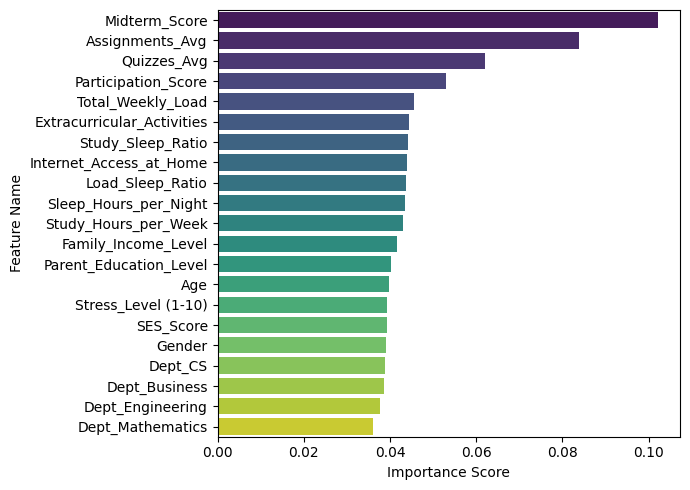

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

best_xgb_extracted = best_xgb_model.named_steps['xgb']

feature_importances = best_xgb_extracted.feature_importances_

feature_names = X_train_encoded.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n=== FEATURE IMPORTANCE (XGBOOST) ===")
print(importance_df)


plt.figure(figsize=(7, 5))

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importance_xgb_with_f.pdf')
plt.show()